In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import random
import numpy as np

In [2]:
import time
import psutil

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN
from semifreddo_full_v2_model_mod import Semifreddo

In [4]:
FOLD = 0

In [5]:
flat_df = pd.read_csv(f"/scratch1/smaruj/genomic_flat_regions/flat_regions_chrom_states_tsv/fold{FOLD}_selected_genomic_windows_centered_chrom_states.tsv", sep="\t")

In [6]:
# 100 strongest CTCFs
ctcf_df = pd.read_csv("/scratch1/smaruj/full_akita_vs_semifreddo/top100_ctcfs.csv")

In [7]:
from pyfaidx import Fasta

In [8]:
genome = Fasta("/project2/fudenber_735/genomes/mm10/mm10.fa")

In [9]:
def get_ctcf_forward_seq(chrom, start, end, strand):
    seq = genome[chrom][start:end].seq
    if strand == "-":
        # reverse complement
        complement = str.maketrans("ACGTacgt", "TGCAtgca")
        seq = seq[::-1].translate(complement)
    return seq.upper()

In [10]:
# Apply to all 100 CTCFs
ctcf_df["ctcf_seq"] = ctcf_df.apply(
    lambda row: get_ctcf_forward_seq(row["chrom"], row["start"], row["end"], row["strand"]), axis=1
)

In [11]:
ctcf_df = ctcf_df[:1]

In [12]:
# add a dummy column to merge on to create a Cartesian product
flat_df["key"] = 1
ctcf_df["key"] = 1

merged_df = pd.merge(flat_df, ctcf_df, on="key", suffixes=("_flat", "_ctcf")).drop(columns="key")

In [ ]:
merged_df

In [13]:
merged_df = merged_df.rename(columns={
    "chrom_flat": "chrom",
    "centered_start": "centered_start",
    "centered_end": "centered_end",
    "chrom_ctcf": "ctcf_chrom",
    "start": "ctcf_start",
    "end": "ctcf_end",
    "strand": "ctcf_strand",
    "ctcf_seq": "ctcf_seq"
})

In [ ]:
# merged_df = merged_df[:10]


In [14]:
len(merged_df)

46

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1798608/ipykernel_2539796/4002068329.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [16]:
def ohe(seq):
    # Example: returns tensor of shape (4, L)
    mapping = {"A":0, "C":1, "G":2, "T":3}
    import torch
    X = torch.zeros(4, len(seq), dtype=torch.float32)
    for i, base in enumerate(seq):
        if base in mapping:
            X[mapping[base], i] = 1.0
    return X

In [17]:
from scipy.stats import pearsonr

In [18]:
bin_size = 2048
n_bins = 5

pred_times_seqnn = []
pred_mem_seqnn = []

# pred_times_seqnn_again = []
# pred_mem_seqnn_again = []

pred_times_sf = []
pred_mem_sf = []

pearsonRs = []

for idx, row in merged_df.iterrows():
    # 1️. Load original sequence X (one-hot)
    X = torch.load(f"/scratch1/smaruj/generate_genomic_boundary/ohe_X/{row['fold']}/{row['chrom']}_{row['centered_start']}_{row['centered_end']}_X.pt",
                   weights_only=True).squeeze(0)
    
    # 2️. One-hot encode CTCF
    ctcf_seq = row["ctcf_seq"]
    ctcf_ohe = ohe(ctcf_seq)
    
    # 3️. Insert CTCF in the middle of X
    seq_len = X.shape[1]
    mid = seq_len // 2
    ctcf_len = ctcf_ohe.shape[1]
    start_idx = mid - ctcf_len // 2
    end_idx = start_idx + ctcf_len
    X[:, start_idx:end_idx] = ctcf_ohe
    
    # 4. Full model prediction
    torch.cuda.reset_peak_memory_stats(device)
    t0 = time.time()
    with torch.no_grad():
        pred_seqnn = model(X.unsqueeze(0).to(device))
    t1 = time.time()
    
    pred_times_seqnn.append(t1 - t0)
    pred_mem_seqnn.append(torch.cuda.max_memory_allocated(device)/1e6)
    
    # # 4. Full model prediction - again
    # torch.cuda.reset_peak_memory_stats(device)
    # t0 = time.time()
    # with torch.no_grad():
    #     pred_seqnn_2 = model(X.unsqueeze(0).to(device))
    # t1 = time.time()
    
    # pred_times_seqnn_again.append(t1 - t0)
    # pred_mem_seqnn_again.append(torch.cuda.max_memory_allocated(device)/1e6)
    
    # 5. Prepare padded slice for Semifreddo (central 5 bins)
    central_start = mid - bin_size//2
    central_end = central_start + bin_size
    slice_start = max(0, central_start - 2*bin_size)
    slice_end = min(seq_len, central_end + 2*bin_size)
    slice_0_padded_seq = X[:, slice_start:slice_end].clone()
    
    # Edited indices relative to padded slice
    edited_indices_slice_0 = [256]
    
    slice_0_padded_seq = slice_0_padded_seq.unsqueeze(0)
    
    # 6. Run Semifreddo
    precom_tensor = torch.load(f"/scratch1/smaruj/generate_genomic_boundary/tower_outputs/{row['fold']}/{row['chrom']}_{row['centered_start']}_{row['centered_end']}_tower_out.pt",
                   weights_only=True).to(device)
    
    semifreddo_instance = Semifreddo(model=model,
                                     slice_0_padded_seq=slice_0_padded_seq,
                                     edited_indices_slice_0=edited_indices_slice_0,
                                     precomputed_full_output=precom_tensor,
                                     cropping_applied=64,
                                     batch_size=1)
    
    torch.cuda.reset_peak_memory_stats(device)
    t0 = time.time()
    with torch.no_grad():
        pred_sf = semifreddo_instance.forward()
    t1 = time.time()
    
    pred_times_sf.append(t1 - t0)
    pred_mem_sf.append(torch.cuda.max_memory_allocated(device)/1e6)
    
    # 7. Compute PearsonR between full and semifreddo predictions
    r, _ = pearsonr(pred_seqnn.flatten().cpu().numpy(), pred_sf.flatten().cpu().numpy())
    pearsonRs.append(r)
    
    # r, _ = pearsonr(pred_seqnn_1.flatten().cpu().numpy(), pred_seqnn_2.flatten().cpu().numpy())
    # pearsonRs.append(r)

In [19]:
merged_df["pred_time_seqnn"] = pred_times_seqnn
merged_df["pred_mem_seqnn_MB"] = pred_mem_seqnn
merged_df["pred_time_sf"] = pred_times_sf
merged_df["pred_mem_sf_MB"] = pred_mem_sf
merged_df["pearsonR"] = pearsonRs

In [20]:
avg_metrics = merged_df[["pred_time_seqnn", "pred_mem_seqnn_MB",
                         "pred_time_sf", "pred_mem_sf_MB", "pearsonR"]].mean()
print(avg_metrics)

pred_time_seqnn         0.009648
pred_mem_seqnn_MB    1714.454038
pred_time_sf            0.004351
pred_mem_sf_MB        540.459954
pearsonR                0.999471
dtype: float64


In [21]:
memory_log = []

def memory_hook(module, input, output, tag=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / (1024 ** 2)
        reserved = torch.cuda.memory_reserved() / (1024 ** 2)
        peak = torch.cuda.max_memory_allocated() / (1024 ** 2)
        
        # Save to list instead of printing
        memory_log.append({
            "layer": f"{tag}{module.__class__.__name__}",
            "allocated_MB": allocated,
            "reserved_MB": reserved,
            "peak_MB": peak
        })

In [22]:
memory_log_sf = []

def memory_hook_sf(module, input, output, tag=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / (1024 ** 2)
        reserved = torch.cuda.memory_reserved() / (1024 ** 2)
        peak = torch.cuda.max_memory_allocated() / (1024 ** 2)
        memory_log_sf.append({
            "layer": f"{tag}{module.__class__.__name__}",
            "allocated_MB": allocated,
            "reserved_MB": reserved,
            "peak_MB": peak
        })

In [24]:
all_mem_logs_seqnn = []
all_mem_logs_sf = []

for idx, row in merged_df.iterrows():
    # 1️. Load original sequence X (one-hot)
    X = torch.load(f"/scratch1/smaruj/generate_genomic_boundary/ohe_X/{row['fold']}/{row['chrom']}_{row['centered_start']}_{row['centered_end']}_X.pt",
                   weights_only=True).squeeze(0)
    
    # 2️. One-hot encode CTCF
    ctcf_seq = row["ctcf_seq"]
    ctcf_ohe = ohe(ctcf_seq)
    
    # 3️. Insert CTCF in the middle of X
    seq_len = X.shape[1]
    mid = seq_len // 2
    ctcf_len = ctcf_ohe.shape[1]
    start_idx = mid - ctcf_len // 2
    end_idx = start_idx + ctcf_len
    X[:, start_idx:end_idx] = ctcf_ohe
    
    for name, module in model.named_modules():
        module.register_forward_hook(
            lambda m, i, o, name=name: memory_hook(m, i, o, tag=f"{name}: ")
        )
    
    # 4. Full model prediction
    # torch.cuda.reset_peak_memory_stats(device)
    memory_log.clear()
    with torch.no_grad():
        pred_seqnn = model(X.unsqueeze(0).to(device))
    df_mem = pd.DataFrame(memory_log)
    
    # 5. Prepare padded slice for Semifreddo (central 5 bins)
    central_start = mid - bin_size//2
    central_end = central_start + bin_size
    slice_start = max(0, central_start - 2*bin_size)
    slice_end = min(seq_len, central_end + 2*bin_size)
    slice_0_padded_seq = X[:, slice_start:slice_end].clone()
    
    # Edited indices relative to padded slice
    edited_indices_slice_0 = [256]
    
    slice_0_padded_seq = slice_0_padded_seq.unsqueeze(0)
    
    memory_log_sf.clear()
    # 6. Run Semifreddo
    precom_tensor = torch.load(f"/scratch1/smaruj/generate_genomic_boundary/tower_outputs/{row['fold']}/{row['chrom']}_{row['centered_start']}_{row['centered_end']}_tower_out.pt",
                   weights_only=True).to(device)
    
    # Pick the layers that Semifreddo actually runs
    for name, module in model.named_modules():
        module.register_forward_hook(
            lambda m, i, o, name=name: memory_hook_sf(m, i, o, tag=f"{name}: ")
        )
    
    semifreddo_instance = Semifreddo(model=model,
                                     slice_0_padded_seq=slice_0_padded_seq,
                                     edited_indices_slice_0=edited_indices_slice_0,
                                     precomputed_full_output=precom_tensor,
                                     cropping_applied=64,
                                     batch_size=1)
    
    with torch.no_grad():
        pred_sf = semifreddo_instance.forward()
    df_mem_sf = pd.DataFrame(memory_log_sf)
    
    # Save memory logs with run info
    df_mem["run"] = idx
    df_mem_sf["run"] = idx

    all_mem_logs_seqnn.append(df_mem)
    all_mem_logs_sf.append(df_mem_sf)

In [25]:
import matplotlib.pyplot as plt

In [31]:
# Concatenate results
df_all_seqnn = pd.concat(all_mem_logs_seqnn, ignore_index=True)
df_all_sf = pd.concat(all_mem_logs_sf, ignore_index=True)

# Average across runs
df_avg_seqnn = df_all_seqnn.groupby("layer", as_index=False)[["allocated_MB","reserved_MB","peak_MB"]].mean()
df_avg_sf = df_all_sf.groupby("layer", as_index=False)[["allocated_MB","reserved_MB","peak_MB"]].mean()

In [33]:
ordered_layer_names = [
    f"{name}: {module.__class__.__name__}"
    for name, module in model.named_modules()
    if name != ""   # skip the top-level empty name which sometimes yields just 'SeqNN' row
]

In [35]:
set_seq = set(df_avg_seqnn["layer"].unique())
set_sf  = set(df_avg_sf["layer"].unique())
common_layers = [name for name in ordered_layer_names if (name in set_seq and name in set_sf)]

In [37]:
df_avg_seqnn_ordered = df_avg_seqnn.set_index("layer").reindex(common_layers).reset_index()
df_avg_sf_ordered     = df_avg_sf.set_index("layer").reindex(common_layers).reset_index()

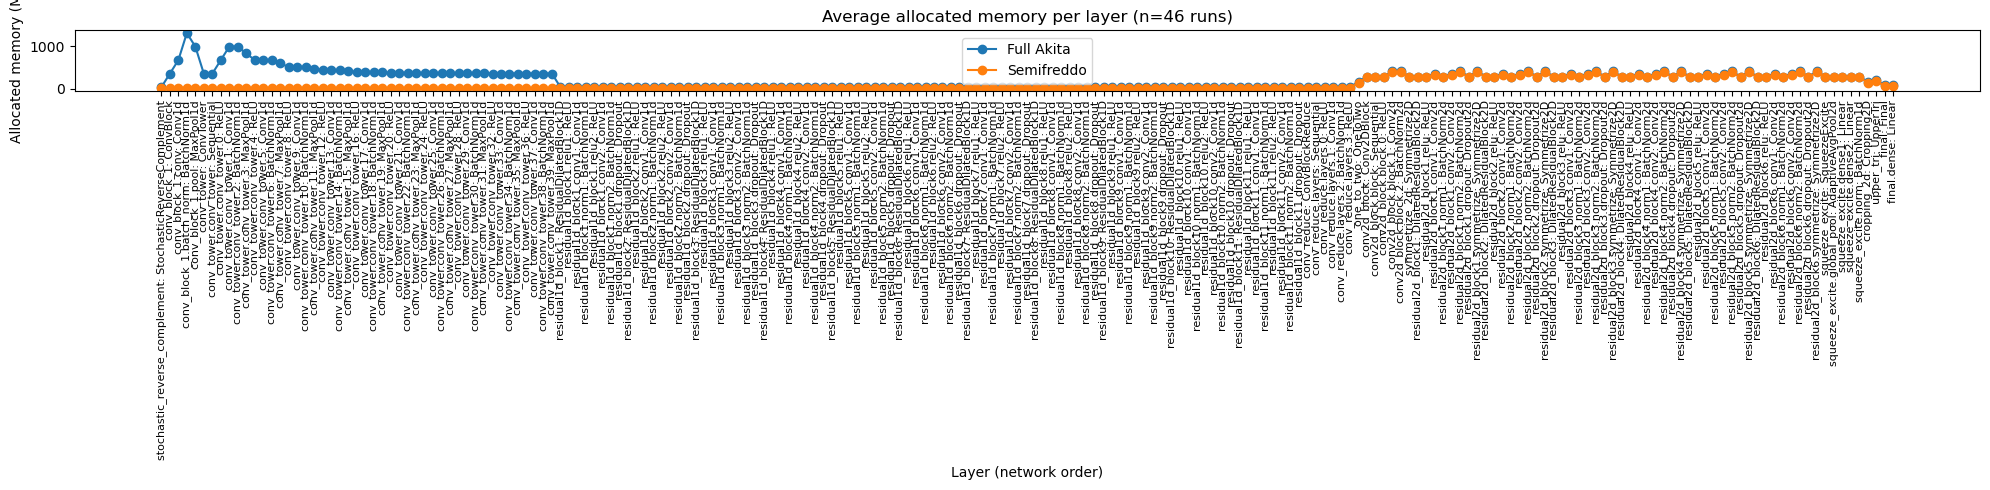

In [41]:
plt.figure(figsize=(20, 5))
x = range(len(common_layers))

plt.plot(x, df_avg_seqnn_ordered["allocated_MB"], marker="o", label="Full Akita")
plt.plot(x, df_avg_sf_ordered["allocated_MB"], marker="o", label="Semifreddo")

plt.xticks(x, df_avg_seqnn_ordered["layer"], rotation=90, fontsize=8)
plt.xlabel("Layer (network order)")
plt.ylabel("Allocated memory (MB)")
plt.title(f"Average allocated memory per layer (n={len(df_all_seqnn['run'].unique())} runs)")
plt.legend()
plt.tight_layout()
plt.show()

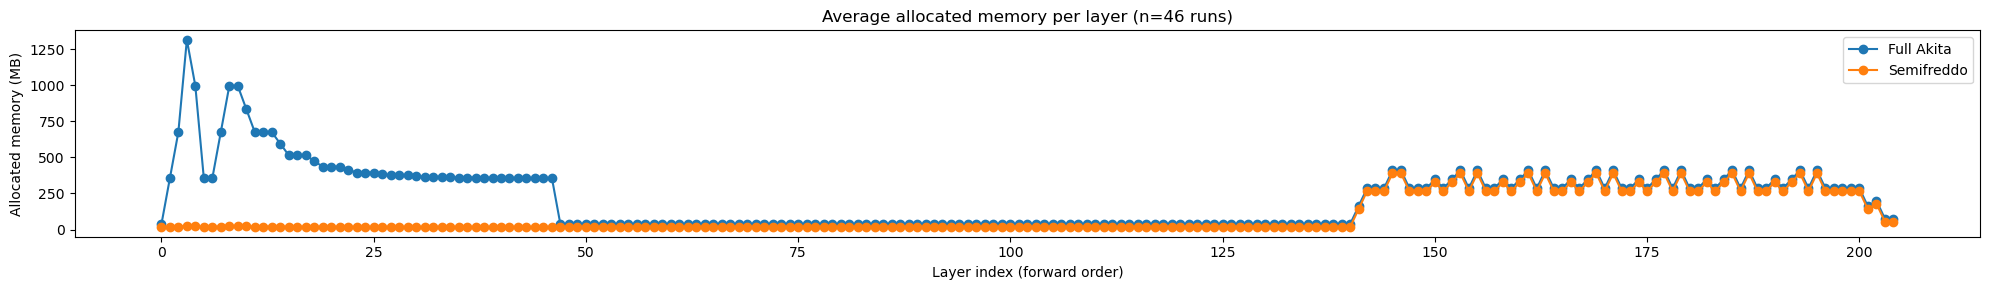

In [49]:
plt.figure(figsize=(20, 3))
x = range(len(common_layers))

plt.plot(x, df_avg_seqnn_ordered["allocated_MB"], marker="o", label="Full Akita")
plt.plot(x, df_avg_sf_ordered["allocated_MB"], marker="o", label="Semifreddo")

plt.xlabel("Layer index (forward order)")
plt.ylabel("Allocated memory (MB)")
plt.title(f"Average allocated memory per layer (n={len(df_all_seqnn['run'].unique())} runs)")
plt.legend()
plt.tight_layout()
plt.show()